            Sales
Date             
2020-01-01    200
2020-02-01    220
2020-03-01    250
2020-04-01    270
2020-05-01    300


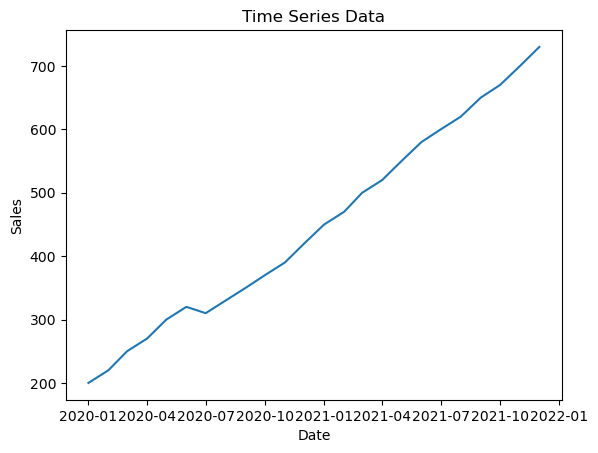

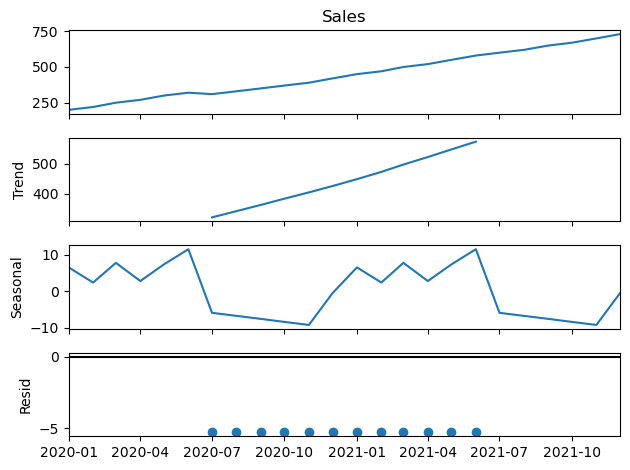

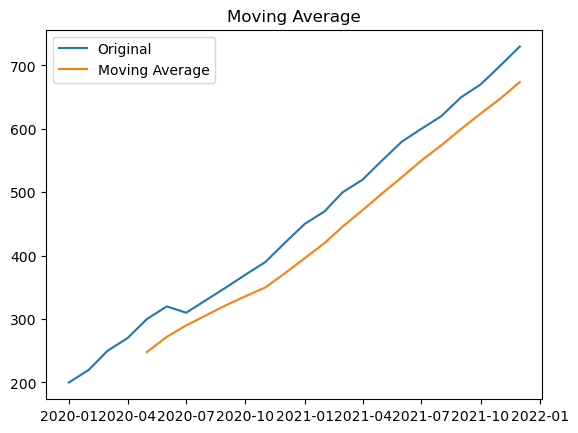

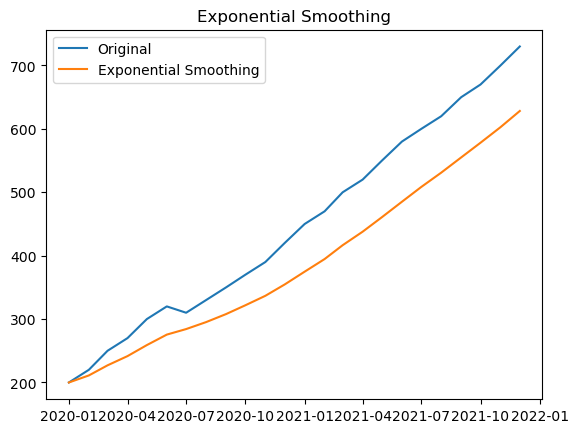

RMSE: 11.010617914283229


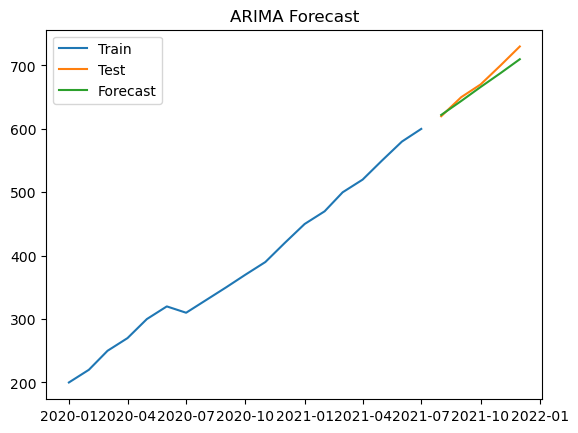

In [4]:
# ================== IMPORT LIBRARIES ==================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")

# ================== LOAD DATASET ==================
# Example: Date + Sales (you can replace with your dataset)
df = pd.read_csv("time_series_data.csv")

# Convert to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Set index
df.set_index('Date', inplace=True)

print(df.head())

# ================== PLOT TIME SERIES ==================
plt.figure()
plt.plot(df['Sales'])
plt.title("Time Series Data")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

# ================== DECOMPOSITION ==================
decomposition = seasonal_decompose(df['Sales'], model='additive', period=12)

decomposition.plot()
plt.show()

# ================== MOVING AVERAGE ==================
df['Moving_Avg'] = df['Sales'].rolling(window=5).mean()

plt.figure()
plt.plot(df['Sales'], label='Original')
plt.plot(df['Moving_Avg'], label='Moving Average')
plt.legend()
plt.title("Moving Average")
plt.show()

# ================== EXPONENTIAL SMOOTHING ==================
df['Exp_Smooth'] = df['Sales'].ewm(alpha=0.2).mean()

plt.figure()
plt.plot(df['Sales'], label='Original')
plt.plot(df['Exp_Smooth'], label='Exponential Smoothing')
plt.legend()
plt.title("Exponential Smoothing")
plt.show()

# ================== TRAIN-TEST SPLIT ==================
train = df['Sales'][:int(len(df)*0.8)]
test = df['Sales'][int(len(df)*0.8):]

# ================== ARIMA MODEL ==================
model = ARIMA(train, order=(2,1,2))
model_fit = model.fit()

# Forecast
forecast = model_fit.forecast(steps=len(test))

# ================== EVALUATION ==================
rmse = np.sqrt(mean_squared_error(test, forecast))
print("RMSE:", rmse)

# ================== PLOT FORECAST ==================
plt.figure()
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(forecast, label='Forecast')
plt.legend()
plt.title("ARIMA Forecast")
plt.show()